# Exploratory Data Analysis: Amazon-Google

Understand the dataset before building features. Key questions:
- What do the tables look like? How many records, what fields, how much missing data?
- What do true match pairs vs non-match pairs look like?
- What patterns will features need to exploit?

In [1]:
import os

PROJECT_ROOT = os.path.expanduser("~/Documents/entity-resolution-pipeline")
os.chdir(PROJECT_ROOT)

import pandas as pd
import matplotlib.pyplot as plt

df_a = pd.read_csv("data/amazon-google/tableA.csv")
df_b = pd.read_csv("data/amazon-google/tableB.csv")
train = pd.read_csv("data/amazon-google/train.csv")
valid = pd.read_csv("data/amazon-google/valid.csv")
test = pd.read_csv("data/amazon-google/test.csv")

print(f"Table A: {len(df_a)} records, columns: {list(df_a.columns)}")
print(f"Table B: {len(df_b)} records, columns: {list(df_b.columns)}")
print(f"Splits: train={len(train)}, valid={len(valid)}, test={len(test)}")
print(f"\nLabel distribution:")
for name, split in [("train", train), ("valid", valid), ("test", test)]:
    pos = split.label.sum()
    print(f"  {name}: {pos} matches / {len(split)} pairs ({pos/len(split)*100:.1f}%)")

Table A: 1363 records, columns: ['id', 'title', 'manufacturer', 'price']
Table B: 3226 records, columns: ['id', 'title', 'manufacturer', 'price']
Splits: train=6874, valid=2293, test=2293

Label distribution:
  train: 699 matches / 6874 pairs (10.2%)
  valid: 234 matches / 2293 pairs (10.2%)
  test: 234 matches / 2293 pairs (10.2%)


## Missing Data

In [2]:
print("Table A missing values:")
print(df_a.isnull().sum())
print(f"\nTable B missing values:")
print(df_b.isnull().sum())
print(f"\nKey: Table B manufacturer is missing {df_b.manufacturer.isnull().sum()}/{len(df_b)} "
      f"({df_b.manufacturer.isnull().mean()*100:.0f}%) -- features must handle NaN gracefully.")

Table A missing values:
id                0
title             0
manufacturer      0
price           199
dtype: int64

Table B missing values:
id                 0
title              0
manufacturer    2870
price              0
dtype: int64

Key: Table B manufacturer is missing 2870/3226 (89%) -- features must handle NaN gracefully.


## Sample Match and Non-Match Pairs

Looking at what the model needs to distinguish.

In [3]:
def show_pairs(split, label_val, n=5):
    subset = split[split.label == label_val].head(n)
    for _, row in subset.iterrows():
        ra = df_a[df_a.id == row.ltable_id].iloc[0]
        rb = df_b[df_b.id == row.rtable_id].iloc[0]
        print(f"  A: {ra.title}")
        print(f"     mfr={ra.manufacturer}, price={ra.price}")
        print(f"  B: {rb.title}")
        print(f"     mfr={rb.manufacturer}, price={rb.price}")
        print()

print("=== TRUE MATCHES ===")
show_pairs(train, 1)
print("=== NON-MATCHES ===")
show_pairs(train, 0)

=== TRUE MATCHES ===
  A: motu digital performer 5 digital audio software competitive upgrade ( mac only )
     mfr=motu, price=395.0
  B: motu digital performer dp5 software music production software
     mfr=nan, price=319.95

  A: illustrator cs3 13 mac ed 1u
     mfr=adobe-education-box, price=199.0
  B: adobe illustrator cs3 for mac academic
     mfr=adobe-education-box, price=199.99

  A: microsoft word 2007 version upgrade
     mfr=microsoft, price=109.95
  B: microsoft word 2007 upgrade ( pc )
     mfr=nan, price=109.95

  A: hoyle : classic collection 2006
     mfr=encore, price=19.99
  B: encore software 11052 hoyle : classic collection 2006 win 98 me 2000 xp
     mfr=nan, price=18.97

  A: reel deal slots 2.0 for pc
     mfr=phantom efx, price=9.99
  B: phantom efx reel deal slots v 2.0
     mfr=nan, price=7.36

=== NON-MATCHES ===
  A: microsoft visio standard 2007 version upgrade
     mfr=microsoft, price=129.95
  B: adobe cs3 design standard upgrade
     mfr=nan, price=41

## Price Distribution

Price is a strong structured signal. How does it distribute across tables?

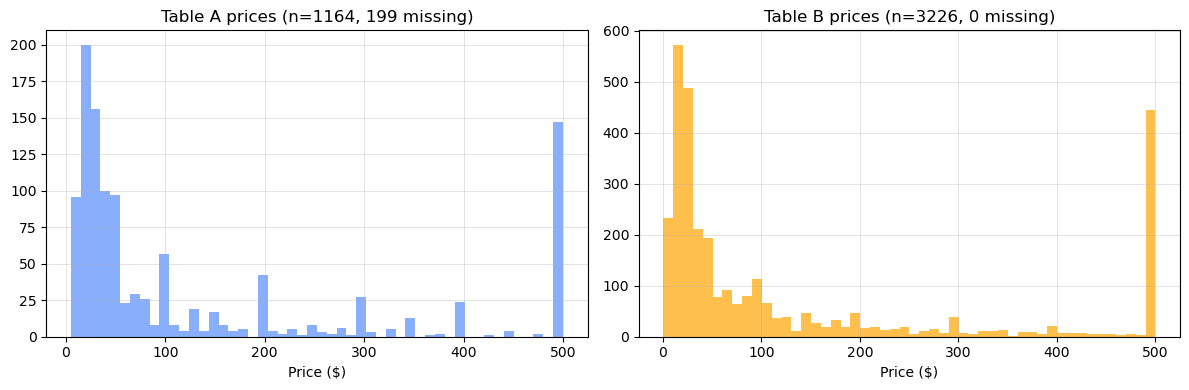

Table A price stats:
count      1164.000000
mean        406.410747
std        3349.624277
min           4.990000
25%          19.990000
50%          49.950000
75%         199.000000
max      101515.550000
Name: price, dtype: float64

Table B price stats:
count      3226.000000
mean       3261.353841
std       21450.401592
min           0.500000
25%          20.970000
50%          47.040000
75%         189.950000
max      443164.000000
Name: price, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_a.price.dropna().clip(upper=500).hist(bins=50, ax=axes[0], alpha=0.7)
axes[0].set_title(f"Table A prices (n={df_a.price.notna().sum()}, {df_a.price.isna().sum()} missing)")
axes[0].set_xlabel("Price ($)")
df_b.price.dropna().clip(upper=500).hist(bins=50, ax=axes[1], alpha=0.7, color="orange")
axes[1].set_title(f"Table B prices (n={df_b.price.notna().sum()}, {df_b.price.isna().sum()} missing)")
axes[1].set_xlabel("Price ($)")
plt.tight_layout()
plt.show()

print(f"Table A price stats:\n{df_a.price.describe()}")
print(f"\nTable B price stats:\n{df_b.price.describe()}")

## Title Length Distribution

Longer titles in Table B suggest more verbose product descriptions.

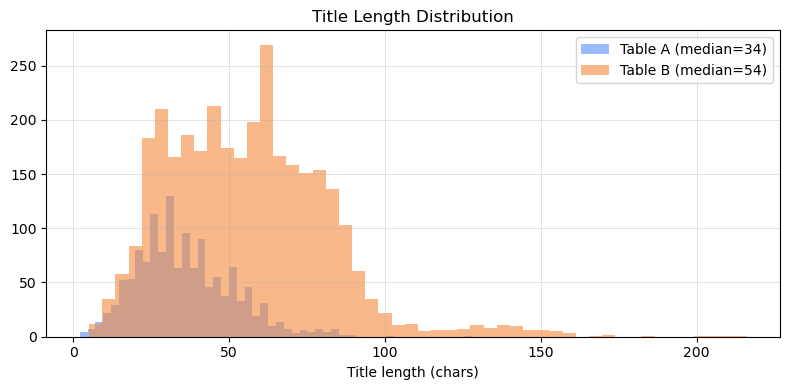

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
df_a.title.str.len().hist(bins=50, ax=ax, alpha=0.6, label=f"Table A (median={df_a.title.str.len().median():.0f})")
df_b.title.str.len().hist(bins=50, ax=ax, alpha=0.6, label=f"Table B (median={df_b.title.str.len().median():.0f})")
ax.set_xlabel("Title length (chars)")
ax.set_title("Title Length Distribution")
ax.legend()
plt.tight_layout()
plt.show()